# Tokopedia ETL Pipeline - Exploratory Data Analysis (EDA)

## Project Overview

Project ini merupakan implementasi sederhana dari ETL (Extract, Transform, Load) Pipeline menggunakan Python.

Tahapan ETL yang dilakukan:

- Extract data produk Tokopedia menggunakan Selenium & BeautifulSoup
- Transform data (Cleaning & Feature Engineering).
- Validate hasil transformasi.
- Load data ke CSV dan SQLite.

Notebook ini digunakan untuk melakukan Exploratory Data Analysis (EDA) terhadap data hasil ETL.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/processed/Data_Seblak_Clean.csv")

df.head()

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,50,5.0,0,NaN,No
1,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Depok,50,4.9,1716000,Mahal,No
2,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No
3,"Rasa Juara Praktis 1 Pcs (Seblak, Cuankie, Bat...",18000,Rasa Juara Indonesia,Kab. Bandung,250,4.7,4500000,Sedang,Yes
4,SUBRON Panci Masak Paket 8IN1 14CM 17CM 6pcs S...,59900,SUBRON KITCHENWARE,Kab. Bandung,40,4.7,2396000,Mahal,No


## Dataset Information

In [5]:
df.shape

(30, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     30 non-null     object 
 1   Price            30 non-null     int64  
 2   Seller           30 non-null     object 
 3   City             30 non-null     object 
 4   Sold             30 non-null     int64  
 5   Rating           30 non-null     float64
 6   Revenue          30 non-null     int64  
 7   Price_Category   26 non-null     object 
 8   Popular_Product  30 non-null     object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.2+ KB


In [7]:
df.describe(include="all")

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
count,30,30.000000,30,30,30.000000,30.000000,3.000000e+01,26,30
unique,30,NaN,9,8,NaN,NaN,NaN,2,2
top,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,NaN,Kylafood,Bandung,NaN,NaN,NaN,Mahal,Yes
freq,1,NaN,10,10,NaN,NaN,NaN,20,19
mean,NaN,41318.100000,NaN,NaN,4367.366667,4.733333,7.377469e+07,NaN,NaN
std,NaN,30335.440437,NaN,NaN,18234.251280,0.174856,2.468722e+08,NaN,NaN
min,NaN,0.000000,NaN,NaN,11.000000,4.200000,0.000000e+00,NaN,NaN
25%,NaN,21250.000000,NaN,NaN,70.000000,4.700000,2.246430e+06,NaN,NaN
50%,NaN,33722.000000,NaN,NaN,250.000000,4.750000,4.900000e+06,NaN,NaN
75%,NaN,59863.000000,NaN,NaN,687.500000,4.800000,3.400400e+07,NaN,NaN


## Missing Value

In [8]:
df.isnull().sum()

Product Name       0
Price              0
Seller             0
City               0
Sold               0
Rating             0
Revenue            0
Price_Category     4
Popular_Product    0
dtype: int64

## Duplicate Data

In [9]:
df.duplicated().sum()

np.int64(0)

## Top 10 Most Expensive Products

In [10]:
df.sort_values("Price", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
14,Kylafood Seblak Rempah Autentik isi (10pcs),128000,Kylafood,Bandung,250,4.8,32000000,Mahal,Yes
17,Kylafood Paket Seblak Cup intant isi 6 PCS Ins...,93188,Kylafood,Bandung,750,4.8,69891000,Mahal,Yes
19,"Kylafood Paket Combo Hemat (2 Seblak Rempah, 2...",84825,Kylafood,Bandung,250,4.8,21206250,Mahal,Yes
28,Kylafood Paket 2 Seblak Cup + 3 Basreng pedas,74360,Kylafood,Bandung,30,4.7,2230800,Mahal,No
29,Kylafood paket Paket 2 Seblak cup + 3 Seblak R...,69344,Kylafood,Bandung,500,4.7,34672000,Mahal,Yes
8,CAP IBU Bumbu Seblak Bandung - Bumbu Masak Ins...,65000,Cap Ibu Shop,Jakarta Timur,250,5.0,16250000,Mahal,Yes
11,1KG KERUPUK SEBLAK JENGKOL PEDAS,60000,CEMILANKU KAYA BUMBU,Kab.Ciamis,80,4.8,4800000,Mahal,No
4,SUBRON Panci Masak Paket 8IN1 14CM 17CM 6pcs S...,59900,SUBRON KITCHENWARE,Kab. Bandung,40,4.7,2396000,Mahal,No
16,Kylafood Paket 2 Seblak Cup + 2 Basreng pedas,59752,Kylafood,Bandung,70,4.8,4182640,Mahal,No
23,"Kylafood Paket (Seblak Cup, Seblak Rempah, Bas...",57333,Kylafood,Bandung,40,4.7,2293320,Mahal,No


## Top 10 Products by Revenue

In [17]:
df.sort_values("Revenue", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
10,STOK TERBATAS ! Kylafood Seblak Rempah Authent...,13350,Kylafood,Bandung,100000,4.8,1335000000,Sedang,Yes
21,Kylafood Paket Seblak Cup instan isi 2 PCS Pedas,33124,Kylafood,Bandung,10000,4.7,331240000,Mahal,Yes
24,Kylafood Seblak Cup isi 1 pcs Jajanan instan,14650,Kylafood,Bandung,10000,4.7,146500000,Sedang,Yes
17,Kylafood Paket Seblak Cup intant isi 6 PCS Ins...,93188,Kylafood,Bandung,750,4.8,69891000,Mahal,Yes
15,Mama Fuji - SEBLAK INSTAN Food Noodles,31999,Mama Fuji Real,Tangerang,2000,4.8,63998000,Mahal,Yes
22,1KG SEBLAK KERUPUK BETON DAUN JERUK / KERUPUK ...,50000,CEMILANKU KAYA BUMBU,Kab.Ciamis,1000,4.7,50000000,Mahal,Yes
25,500GR SEBLAK KERUPUK BETON DAUN JERUK Cemilan ...,25000,CEMILANKU KAYA BUMBU,Kab.Ciamis,2000,4.7,50000000,Sedang,Yes
29,Kylafood paket Paket 2 Seblak cup + 3 Seblak R...,69344,Kylafood,Bandung,500,4.7,34672000,Mahal,Yes
14,Kylafood Seblak Rempah Autentik isi (10pcs),128000,Kylafood,Bandung,250,4.8,32000000,Mahal,Yes
19,"Kylafood Paket Combo Hemat (2 Seblak Rempah, 2...",84825,Kylafood,Bandung,250,4.8,21206250,Mahal,Yes


## Revenue by Seller

In [18]:
seller_revenue = (
    df.groupby("Seller")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

seller_revenue

Seller
Kylafood                       1979216010
CEMILANKU KAYA BUMBU            115550000
Mama Fuji Real                   63998000
Cap Ibu Shop                     16250000
KUKARASA SNACK                   13049739
SUBRON KITCHENWARE               11811000
Pisang Goreng Madu Bu Nanik       7150000
Rasa Juara Indonesia              4500000
Mizanstore.id                     1716000
Name: Revenue, dtype: int64

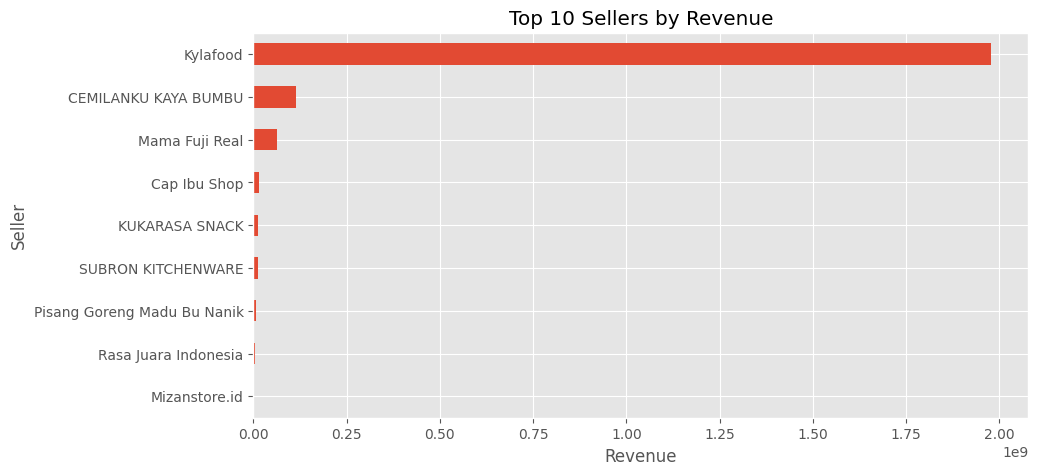

In [19]:
plt.figure(figsize=(10,5))

seller_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller")

plt.show()

## Product Distribution by Price Category

In [20]:
df["Price_Category"].value_counts()

Price_Category
Mahal     20
Sedang     6
Name: count, dtype: int64

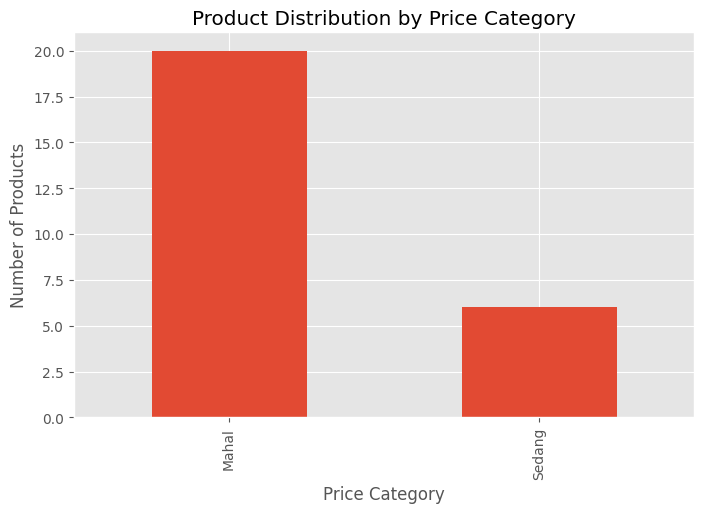

In [21]:
plt.figure(figsize=(8,5))

df["Price_Category"].value_counts().plot(kind="bar")

plt.title("Product Distribution by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Products")

plt.show()

## Popular Product Distribution

In [22]:
df["Popular_Product"].value_counts()

Popular_Product
Yes    19
No     11
Name: count, dtype: int64

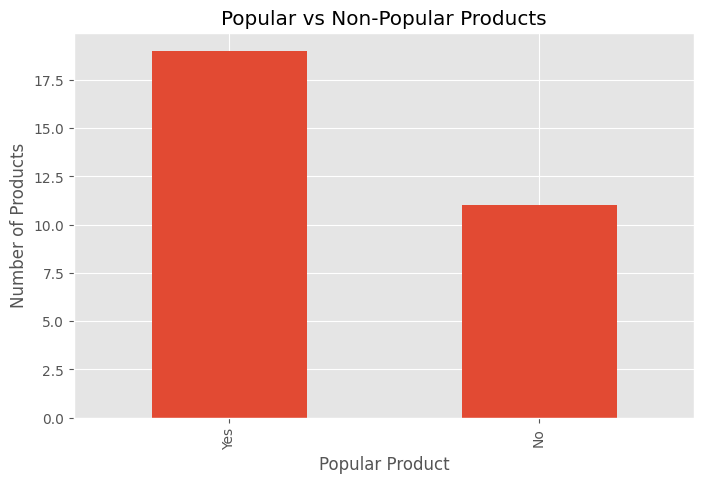

In [23]:
plt.figure(figsize=(8,5))

df["Popular_Product"].value_counts().plot(kind="bar")

plt.title("Popular vs Non-Popular Products")
plt.xlabel("Popular Product")
plt.ylabel("Number of Products")

plt.show()

## Top Seller

In [11]:
df["Seller"].value_counts().head(10)

Seller
Kylafood                       10
CEMILANKU KAYA BUMBU            6
Rasa Juara Indonesia            5
SUBRON KITCHENWARE              3
KUKARASA SNACK                  2
Pisang Goreng Madu Bu Nanik     1
Cap Ibu Shop                    1
Mizanstore.id                   1
Mama Fuji Real                  1
Name: count, dtype: int64

## Top City

In [12]:
df["City"].value_counts().head(10)

City
Bandung             10
Kab. Bandung         8
Kab.Ciamis           6
Kab. Tasikmalaya     2
Jakarta Barat        1
Jakarta Timur        1
Depok                1
Tangerang            1
Name: count, dtype: int64

## Highest Rated Products

In [13]:
df.sort_values("Rating", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,50,5.0,0,NaN,No
9,Seblak Kuah Instan Ibro Bandung,28600,Pisang Goreng Madu Bu Nanik,Jakarta Barat,250,5.0,7150000,Mahal,Yes
8,CAP IBU Bumbu Seblak Bandung - Bumbu Masak Ins...,65000,Cap Ibu Shop,Jakarta Timur,250,5.0,16250000,Mahal,Yes
1,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Depok,50,4.9,1716000,Mahal,No
2,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No
11,1KG KERUPUK SEBLAK JENGKOL PEDAS,60000,CEMILANKU KAYA BUMBU,Kab.Ciamis,80,4.8,4800000,Mahal,No
12,Seblak Juara - Seblak Instan Asli Bandung | Ot...,0,Rasa Juara Indonesia,Kab. Bandung,2000,4.8,0,NaN,Yes
13,500GR SEBLAK KRUPUK RAFAEL VIRAL,40000,CEMILANKU KAYA BUMBU,Kab.Ciamis,100,4.8,4000000,Mahal,Yes
10,STOK TERBATAS ! Kylafood Seblak Rempah Authent...,13350,Kylafood,Bandung,100000,4.8,1335000000,Sedang,Yes
18,1KG SEBLAK CAMPUR DAUN JERUK,25000,CEMILANKU KAYA BUMBU,Kab.Ciamis,70,4.8,1750000,Sedang,No


## Relationship Between Price and Sold

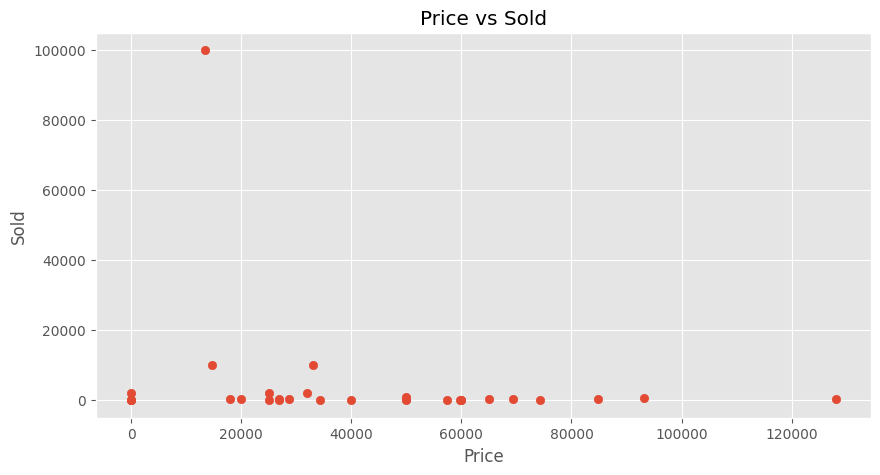

In [24]:
plt.figure(figsize=(10,5))

plt.scatter(df["Price"], df["Sold"])

plt.title("Price vs Sold")
plt.xlabel("Price")
plt.ylabel("Sold")

plt.show()

## Relationship Between Sold and Revenue

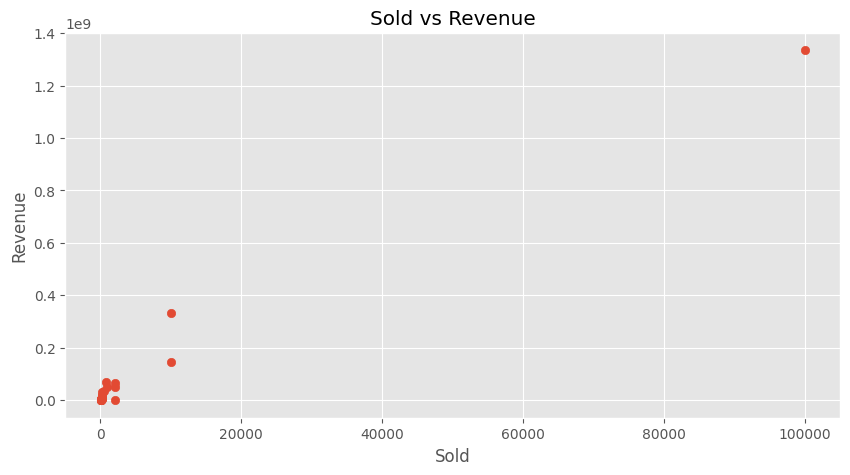

In [25]:
plt.figure(figsize=(10,5))

plt.scatter(df["Sold"], df["Revenue"])

plt.title("Sold vs Revenue")
plt.xlabel("Sold")
plt.ylabel("Revenue")

plt.show()

## Distribution of Product Price

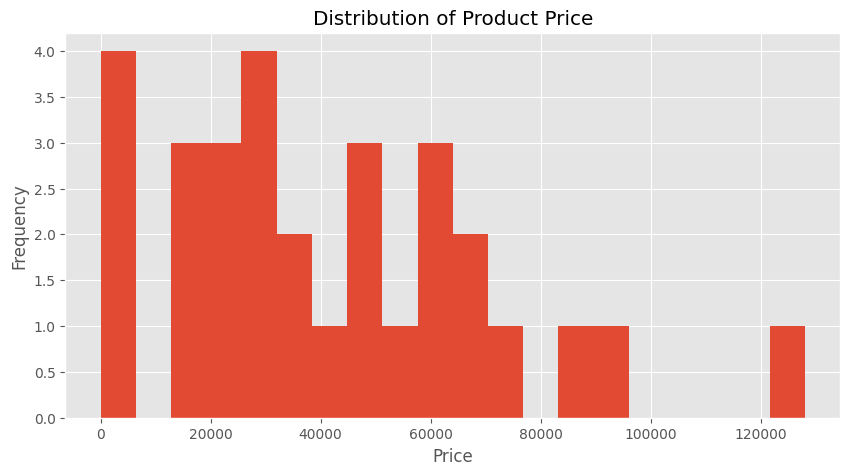

In [14]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Product Price")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

## Distribution of Rating

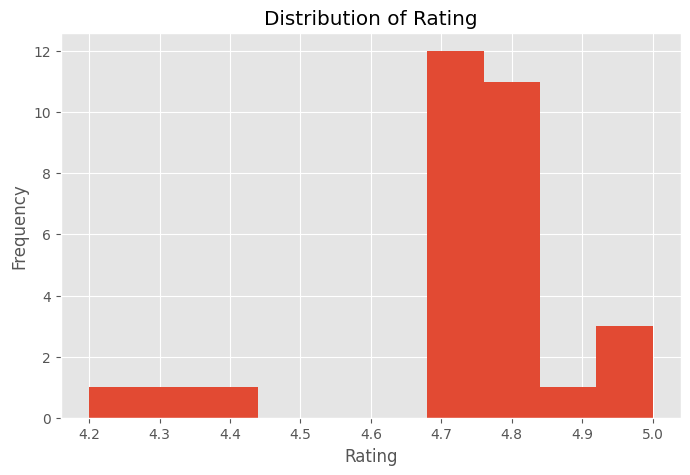

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Distribution of Rating")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

## Top 10 Most Sold Products

In [16]:
df.sort_values("Sold", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
10,STOK TERBATAS ! Kylafood Seblak Rempah Authent...,13350,Kylafood,Bandung,100000,4.8,1335000000,Sedang,Yes
21,Kylafood Paket Seblak Cup instan isi 2 PCS Pedas,33124,Kylafood,Bandung,10000,4.7,331240000,Mahal,Yes
24,Kylafood Seblak Cup isi 1 pcs Jajanan instan,14650,Kylafood,Bandung,10000,4.7,146500000,Sedang,Yes
25,500GR SEBLAK KERUPUK BETON DAUN JERUK Cemilan ...,25000,CEMILANKU KAYA BUMBU,Kab.Ciamis,2000,4.7,50000000,Sedang,Yes
15,Mama Fuji - SEBLAK INSTAN Food Noodles,31999,Mama Fuji Real,Tangerang,2000,4.8,63998000,Mahal,Yes
12,Seblak Juara - Seblak Instan Asli Bandung | Ot...,0,Rasa Juara Indonesia,Kab. Bandung,2000,4.8,0,NaN,Yes
22,1KG SEBLAK KERUPUK BETON DAUN JERUK / KERUPUK ...,50000,CEMILANKU KAYA BUMBU,Kab.Ciamis,1000,4.7,50000000,Mahal,Yes
17,Kylafood Paket Seblak Cup intant isi 6 PCS Ins...,93188,Kylafood,Bandung,750,4.8,69891000,Mahal,Yes
29,Kylafood paket Paket 2 Seblak cup + 3 Seblak R...,69344,Kylafood,Bandung,500,4.7,34672000,Mahal,Yes
14,Kylafood Seblak Rempah Autentik isi (10pcs),128000,Kylafood,Bandung,250,4.8,32000000,Mahal,Yes


## Insight

### Summary

- Dataset berhasil diambil menggunakan Selenium dan BeautifulSoup.
- Data telah dibersihkan melalui proses ETL Pipeline.
- Missing value telah ditangani pada tahap Transform.
- Duplicate data telah dihapus.
- Dataset disimpan dalam format CSV dan SQLite.
- Mayoritas produk memiliki harga pada rentang harga menengah.
- Sebagian besar produk memiliki rating tinggi (>4.5).
- Beberapa seller mendominasi jumlah produk pada hasil scraping.

In [26]:
top_product = df.loc[df["Revenue"].idxmax()]

print("Top Revenue Product:")
print(top_product["Product Name"])

print("\nRevenue:")
print(top_product["Revenue"])

print("\nSold:")
print(top_product["Sold"])

Top Revenue Product:
STOK TERBATAS ! Kylafood Seblak Rempah Authentik Instan Kuah

Revenue:
1335000000

Sold:
100000


In [27]:
top_seller = (
    df.groupby("Seller")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("Top Seller by Revenue:", top_seller)

Top Seller by Revenue: Kylafood


In [28]:
top_seller = (
    df.groupby("Seller")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("Top Seller by Revenue:", top_seller)

Top Seller by Revenue: Kylafood


In [29]:
print("Average Product Price:", df["Price"].mean())
print("Average Rating:", df["Rating"].mean())
print("Total Sold:", df["Sold"].sum())
print("Total Revenue:", df["Revenue"].sum())

Average Product Price: 41318.1
Average Rating: 4.7333333333333325
Total Sold: 131021
Total Revenue: 2213240749


-------------------------------------------------------------------------------------------

## Dataset Overview

In [30]:
print("Shape:", df.shape)

display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())


Shape: (30, 9)


,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,50,5.0,0,NaN,No
1,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Depok,50,4.9,1716000,Mahal,No
2,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No
3,"Rasa Juara Praktis 1 Pcs (Seblak, Cuankie, Bat...",18000,Rasa Juara Indonesia,Kab. Bandung,250,4.7,4500000,Sedang,Yes
4,SUBRON Panci Masak Paket 8IN1 14CM 17CM 6pcs S...,59900,SUBRON KITCHENWARE,Kab. Bandung,40,4.7,2396000,Mahal,No



Data Types:


Product Name        object
Price                int64
Seller              object
City                object
Sold                 int64
Rating             float64
Revenue              int64
Price_Category      object
Popular_Product     object
dtype: object


Missing Values:


Product Name       0
Price              0
Seller             0
City               0
Sold               0
Rating             0
Revenue            0
Price_Category     4
Popular_Product    0
dtype: int64


Duplicate Rows: 0

Statistical Summary:


,Price,Sold,Rating,Revenue
count,30.000000,30.000000,30.000000,3.000000e+01
mean,41318.100000,4367.366667,4.733333,7.377469e+07
std,30335.440437,18234.251280,0.174856,2.468722e+08
min,0.000000,11.000000,4.200000,0.000000e+00
25%,21250.000000,70.000000,4.700000,2.246430e+06
50%,33722.000000,250.000000,4.750000,4.900000e+06
75%,59863.000000,687.500000,4.800000,3.400400e+07
max,128000.000000,100000.000000,5.000000,1.335000e+09


Dataset hasil ETL terdiri dari X records dan Y columns. Setelah proses cleaning dan validation, tidak ditemukan missing value pada kolom utama dan tidak terdapat duplicate records. Hal ini menunjukkan bahwa data sudah berada dalam kondisi yang lebih siap untuk proses downstream.

## Data Quality Analysis

In [31]:
# Missing values
missing = df.isnull().sum()

# Duplicate
duplicates = df.duplicated().sum()

# Invalid values
invalid_price = (df["Price"] < 0).sum()
invalid_sold = (df["Sold"] < 0).sum()
invalid_revenue = (df["Revenue"] < 0).sum()

# Rating biasanya 0-5
invalid_rating = (
    ((df["Rating"] < 0) | (df["Rating"] > 5))
).sum()

print("Missing values:")
display(missing)

print("Duplicate rows:", duplicates)

print("Invalid Price:", invalid_price)
print("Invalid Sold:", invalid_sold)
print("Invalid Revenue:", invalid_revenue)
print("Invalid Rating:", invalid_rating)

Missing values:


Product Name       0
Price              0
Seller             0
City               0
Sold               0
Rating             0
Revenue            0
Price_Category     4
Popular_Product    0
dtype: int64

Duplicate rows: 0
Invalid Price: 0
Invalid Sold: 0
Invalid Revenue: 0
Invalid Rating: 0


Data quality checks menunjukkan bahwa data hasil transformation telah memenuhi constraint dasar seperti tidak memiliki nilai negatif pada price, sold, dan revenue serta rating berada dalam range yang valid. Hasil ini menunjukkan bahwa proses cleaning dan validation pada pipeline berhasil mengurangi data anomaly sebelum proses loading.

## Distribution Analysis

### Price

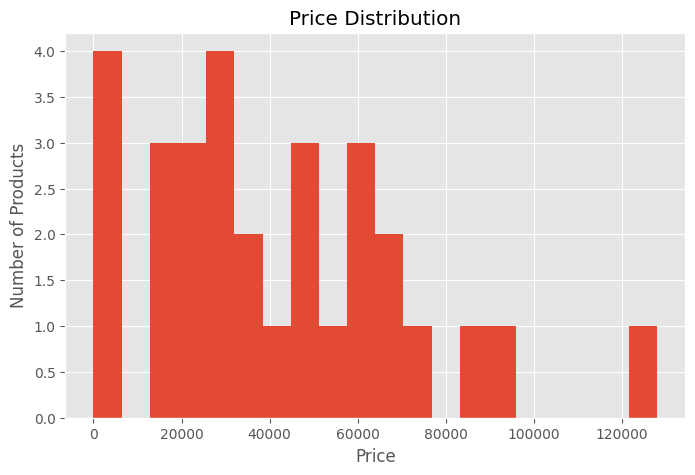

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

### Sold

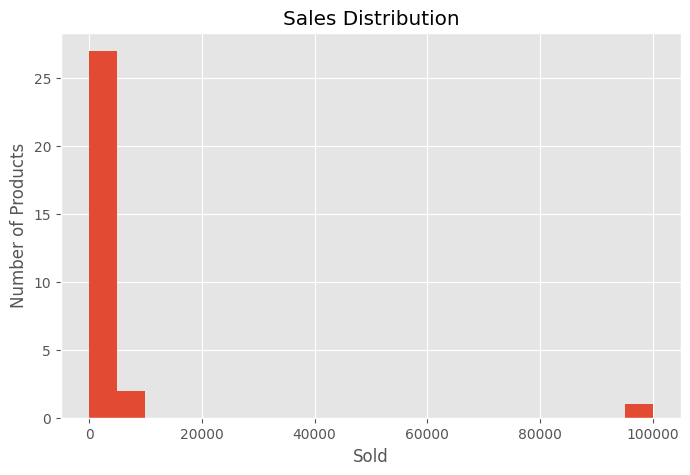

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["Sold"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sold")
plt.ylabel("Number of Products")
plt.show()

### Revenue

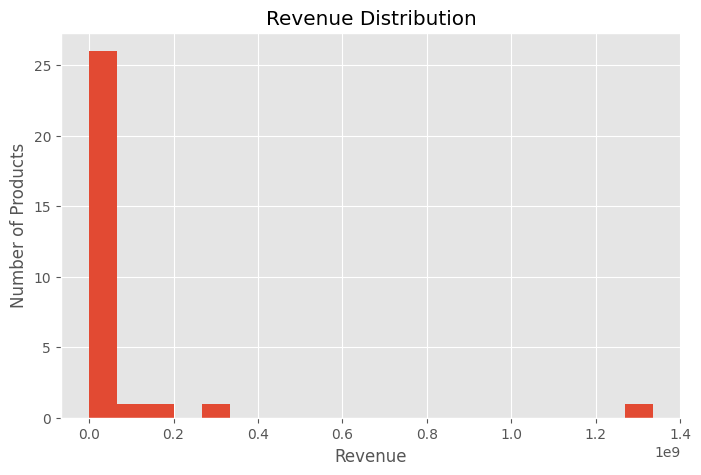

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Products")
plt.show()

Distribusi sales dan revenue menunjukkan bahwa performa produk tidak tersebar secara merata. Sebagian produk memiliki volume penjualan dan revenue yang jauh lebih tinggi dibandingkan produk lainnya, sehingga terdapat indikasi adanya outlier atau konsentrasi performa pada produk tertentu.

## Feature Analysis

### Price Category

In [35]:
display(
    df["Price_Category"]
    .value_counts()
)

Price_Category
Mahal     20
Sedang     6
Name: count, dtype: int64

In [36]:
display(
    df.groupby("Price_Category")
      .agg(
          avg_price=("Price", "mean"),
          avg_sold=("Sold", "mean"),
          avg_revenue=("Revenue", "mean"),
          product_count=("Price", "count")
      )
)

,avg_price,avg_sold,avg_revenue,product_count
Price_Category,,,,
Mahal,56177.150000,813.550000,3.352454e+07,20
Sedang,19333.333333,18761.666667,2.571250e+08,6



### Popular Product

In [37]:
display(
    df.groupby("Popular_Product")
      .agg(
          avg_sold=("Sold", "mean"),
          avg_revenue=("Revenue", "mean"),
          avg_rating=("Rating", "mean"),
          product_count=("Price", "count")
      )
)

,avg_sold,avg_revenue,avg_rating,product_count
Popular_Product,,,,
No,51.909091,1.810795e+06,4.745455,11
Yes,6865.789474,1.154380e+08,4.726316,19


Feature engineering menghasilkan Price_Category dan Popular_Product yang dapat digunakan untuk segmentasi produk. Perbandingan antarsegmen menunjukkan adanya perbedaan performa berdasarkan harga dan tingkat popularitas produk.

## Relationship / Correlation Analysis

### Price and Sold

In [38]:
print(
    "Price vs Sold correlation:",
    df["Price"].corr(df["Sold"])
)

Price vs Sold correlation: -0.19950518457432678


### Sold vs Revenue

In [39]:
print(
    "Sold vs Revenue correlation:",
    df["Sold"].corr(df["Revenue"])
)

Sold vs Revenue correlation: 0.9880723410745667


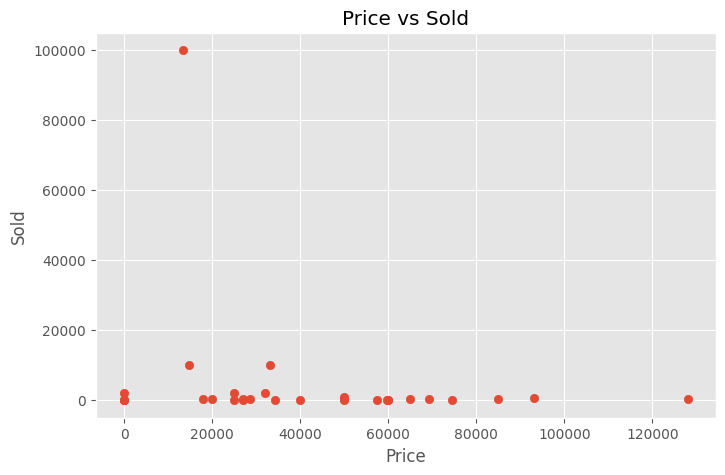

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Price"],
    df["Sold"]
)

plt.title("Price vs Sold")
plt.xlabel("Price")
plt.ylabel("Sold")

plt.show()

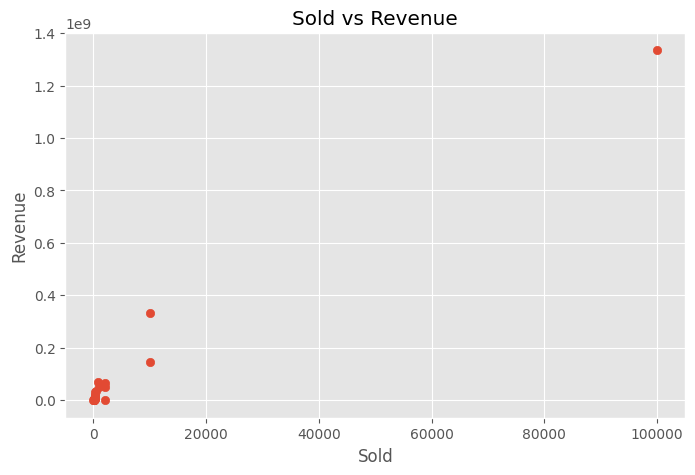

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Sold"],
    df["Revenue"]
)

plt.title("Sold vs Revenue")
plt.xlabel("Sold")
plt.ylabel("Revenue")

plt.show()

Hubungan antara price dan sold relatif lemah dan negatif, sehingga harga bukan satu-satunya faktor yang menentukan volume penjualan pada dataset ini.

## Business / Data Insights

## Key Insights

1. **Data Quality**
   Data hasil ETL telah melewati proses cleaning dan validation sehingga
   missing values, duplicate records, dan invalid values dapat dikendalikan.

2. **Sales Distribution**
   Penjualan produk tidak tersebar secara merata. Sebagian produk memiliki
   volume penjualan jauh lebih tinggi dibandingkan produk lainnya.

3. **Revenue**
   Produk dengan volume penjualan tinggi cenderung memberikan kontribusi
   revenue yang lebih besar, meskipun harga produk tetap menjadi faktor penting.

4. **Price Category**
   Performa produk berbeda antar kategori harga, sehingga segmentasi harga
   dapat digunakan untuk analisis lebih lanjut.

5. **Popular Product**
   Feature Popular_Product dapat digunakan untuk membedakan produk dengan
   performa penjualan tinggi dan produk lainnya.